In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def extract_pulse_amplitudes(file_path, data_format='int16', chunk_size=10_000_000, invert_signal=False):
    """
    Reads PMT data in chunks from disk, finds pulse peaks, and returns them.
    This prevents MemoryErrors on extremely large files.
    """
    if not os.path.exists(file_path):
        print(f"Error: File '{file_path}' not found.")
        return []

    # 1. Use memmap to map the file from disk without loading it all into RAM
    data = np.memmap(file_path, dtype=data_format, mode='r')
    total_points = len(data)
    
    # Pulse parameters
    noise_threshold = 50
    min_samples_between_pulses = 10 
    
    # Create an overlap buffer so we don't split a pulse across two chunks
    overlap = min_samples_between_pulses * 2 
    
    all_peak_amplitudes = []

    # 2. Process the file in chunks
    for start_idx in range(0, total_points, chunk_size):
        end_idx = min(start_idx + chunk_size + overlap, total_points)
        
        # Extract just this specific chunk into active memory
        chunk = data[start_idx:end_idx]
        
        if invert_signal:
            analyze_chunk = chunk * -1
        else:
            analyze_chunk = chunk
            
        # Find peaks in this chunk
        peaks, _ = find_peaks(analyze_chunk, height=noise_threshold, distance=min_samples_between_pulses)
        
        # 3. Prevent double-counting in the overlap region
        if end_idx < total_points:
            valid_peaks = peaks[peaks < chunk_size]
        else:
            valid_peaks = peaks
            
        # Get the actual voltage values for these peaks
        chunk_amplitudes = chunk[valid_peaks]
        all_peak_amplitudes.extend(chunk_amplitudes)
        
    print(f"  -> Found {len(all_peak_amplitudes):,} pulses (processed {total_points:,} points).")
    
    return all_peak_amplitudes

def plot_amplitude_histogram(amplitudes, num_bins=512, log_scale=True):
    """
    Takes an array of pulse amplitudes and plots them as a histogram (spectrum).
    """
    if amplitudes is None or len(amplitudes) == 0:
        print("Error: The amplitudes array is empty. No pulses were found.")
        return

    print(f"\nPlotting combined histogram for {len(amplitudes):,} detected pulses...")

    plt.figure(figsize=(10, 6))
    
    # Plot the histogram using 'stepfilled'
    counts, bins, patches = plt.hist(amplitudes, bins=num_bins, color='mediumseagreen', 
                                     alpha=0.75, histtype='stepfilled', edgecolor='darkgreen')
    
    # Apply Logarithmic Scale
    if log_scale:
        plt.yscale('log')
        plt.grid(True, linestyle='--', alpha=0.6, which='both') 
    else:
        plt.grid(True, linestyle='--', alpha=0.6)

    # Stats
    mean_amp = np.mean(amplitudes)
    max_amp = np.max(amplitudes)
    
    plt.title(f"Combined PMT Pulse Amplitude Spectrum\n(Total Pulses: {len(amplitudes):,})", fontsize=14)
    plt.xlabel("Pulse Amplitude", fontsize=12)
    plt.ylabel("Counts per Bin", fontsize=12)
    
    # Add a text box with statistics
    stats_text = f"Mean Amp: {mean_amp:.4f} \nMax Amp: {max_amp:.4f}"
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()


# ==========================================
# Main Execution Block
# ==========================================

# 1. Define the folder containing your files
folder_path = r"C:\Users\Berkeley\Documents\CERES\pmt100k_hz_files"

# 2. Find all .BINPMT files in that folder
file_pattern = os.path.join(folder_path, "*.BINPMT")
file_list = glob.glob(file_pattern)

if not file_list:
    print(f"No .BINPMT files found in {folder_path}")
else:
    print(f"Found {len(file_list)} files to process.\n")

    # List to hold all amplitudes across all files
    all_amplitudes = []

    # 3. Loop through the files
    for file_path in file_list:
        file_name = os.path.basename(file_path)
        print(f"Processing: {file_name}")
        
        # Extract pulses (processing in chunks to save memory)
        # Replaced num_points with chunk_size
        file_amplitudes = extract_pulse_amplitudes(file_path, chunk_size=10_000_000, invert_signal=False)
        
        # Add the extracted amplitudes to our master list
        if file_amplitudes is not None and len(file_amplitudes) > 0:
            all_amplitudes.extend(file_amplitudes)

    # 4. Convert the combined list to a numpy array for plotting
    all_amplitudes = np.array(all_amplitudes)

    # 5. Plot the combined spectrum!
    plot_amplitude_histogram(all_amplitudes, num_bins=2048, log_scale=True)

Found 3 files to process.

Processing: 20260430_16h07.BINPMT
  -> Found 465,782 pulses (processed 1,001,000,000 points).
Processing: 20260430_17h30.BINPMT
  -> Found 423,804 pulses (processed 1,001,000,000 points).
Processing: 20260430_18h54.BINPMT
  -> Found 212,274 pulses (processed 486,000,000 points).

Plotting combined histogram for 1,101,860 detected pulses...


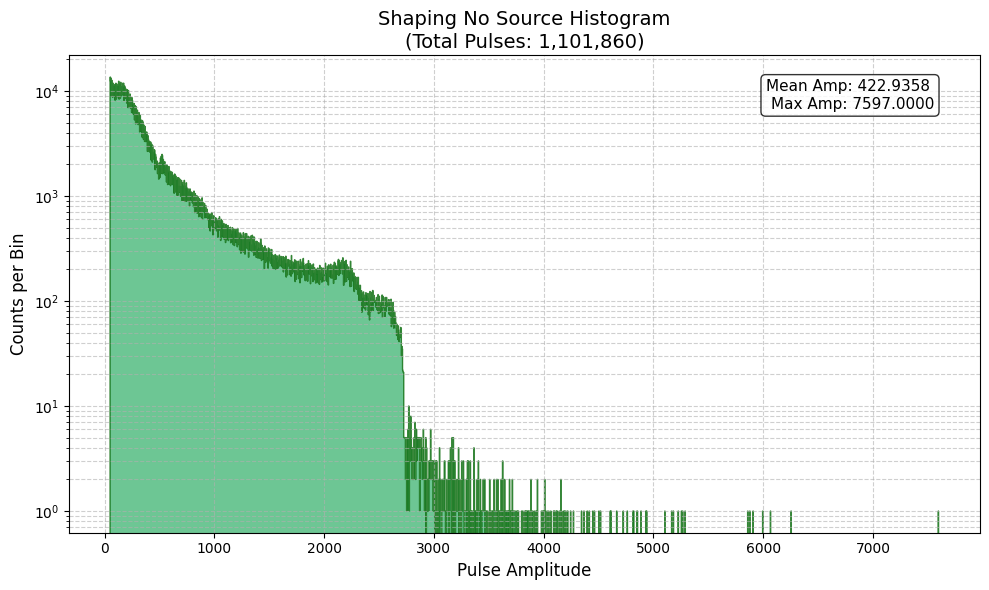

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def extract_pulse_amplitudes(file_path, data_format='int16', chunk_size=10_000_000, invert_signal=False):
    """
    Reads PMT data in chunks from disk, finds pulse peaks, and returns them.
    This prevents MemoryErrors on extremely large files.
    """
    if not os.path.exists(file_path):
        print(f"Error: File '{file_path}' not found.")
        return []

    # 1. Use memmap to map the file from disk without loading it all into RAM
    data = np.memmap(file_path, dtype=data_format, mode='r')
    total_points = len(data)
    
    # Pulse parameters
    noise_threshold = 50
    min_samples_between_pulses = 10 
    
    # Create an overlap buffer so we don't split a pulse across two chunks
    overlap = min_samples_between_pulses * 2 
    
    all_peak_amplitudes = []

    # 2. Process the file in chunks
    for start_idx in range(0, total_points, chunk_size):
        end_idx = min(start_idx + chunk_size + overlap, total_points)
        
        # Extract just this specific chunk into active memory
        chunk = data[start_idx:end_idx]
        
        if invert_signal:
            analyze_chunk = chunk * -1
        else:
            analyze_chunk = chunk
            
        # Find peaks in this chunk
        peaks, _ = find_peaks(analyze_chunk, height=noise_threshold, distance=min_samples_between_pulses)
        
        # 3. Prevent double-counting in the overlap region
        if end_idx < total_points:
            valid_peaks = peaks[peaks < chunk_size]
        else:
            valid_peaks = peaks
            
        # Get the actual voltage values for these peaks
        chunk_amplitudes = chunk[valid_peaks]
        all_peak_amplitudes.extend(chunk_amplitudes)
        
    print(f"  -> Found {len(all_peak_amplitudes):,} pulses (processed {total_points:,} points).")
    
    return all_peak_amplitudes

def plot_amplitude_histogram(amplitudes, num_bins=512, log_scale=True):
    """
    Takes an array of pulse amplitudes and plots them as a histogram (spectrum).
    """
    if amplitudes is None or len(amplitudes) == 0:
        print("Error: The amplitudes array is empty. No pulses were found.")
        return

    print(f"\nPlotting combined histogram for {len(amplitudes):,} detected pulses...")

    plt.figure(figsize=(10, 6))
    
    # Plot the histogram using 'stepfilled'
    counts, bins, patches = plt.hist(amplitudes, bins=num_bins, color='mediumseagreen', 
                                     alpha=0.75, histtype='stepfilled', edgecolor='darkgreen')
    
    # Apply Logarithmic Scale
    if log_scale:
        plt.yscale('log')
        plt.grid(True, linestyle='--', alpha=0.6, which='both') 
    else:
        plt.grid(True, linestyle='--', alpha=0.6)

    # Stats
    mean_amp = np.mean(amplitudes)
    max_amp = np.max(amplitudes)
    
    plt.title(f"Shaping No Source Histogram\n(Total Pulses: {len(amplitudes):,})", fontsize=14)
    plt.xlabel("Pulse Amplitude", fontsize=12)
    plt.ylabel("Counts per Bin", fontsize=12)
    
    # Add a text box with statistics
    stats_text = f"Mean Amp: {mean_amp:.4f} \nMax Amp: {max_amp:.4f}"
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()


# ==========================================
# Main Execution Block
# ==========================================

# 1. Define the folder containing your files
folder_path = r"C:\Users\Berkeley\Documents\CERES\shaping_nosource"

# 2. Find all .BINPMT files in that folder
file_pattern = os.path.join(folder_path, "*.BINPMT")
file_list = glob.glob(file_pattern)

if not file_list:
    print(f"No .BINPMT files found in {folder_path}")
else:
    print(f"Found {len(file_list)} files to process.\n")

    # List to hold all amplitudes across all files
    all_amplitudes = []

    # 3. Loop through the files
    for file_path in file_list:
        file_name = os.path.basename(file_path)
        print(f"Processing: {file_name}")
        
        # Extract pulses (processing in chunks to save memory)
        # Replaced num_points with chunk_size
        file_amplitudes = extract_pulse_amplitudes(file_path, chunk_size=10_000_000, invert_signal=False)
        
        # Add the extracted amplitudes to our master list
        if file_amplitudes is not None and len(file_amplitudes) > 0:
            all_amplitudes.extend(file_amplitudes)

    # 4. Convert the combined list to a numpy array for plotting
    all_amplitudes = np.array(all_amplitudes)

    # 5. Plot the combined spectrum!
    plot_amplitude_histogram(all_amplitudes, num_bins=2048, log_scale=True)

Found 7 files to process.

Processing: 20260421_21h27.BINPMT
  -> Found 1,296,167 pulses (processed 1,001,000,000 points).
Processing: 20260421_22h50.BINPMT
  -> Found 1,297,070 pulses (processed 1,001,000,000 points).
Processing: 20260422_00h13.BINPMT
  -> Found 1,297,269 pulses (processed 1,001,000,000 points).
Processing: 20260422_01h37.BINPMT
  -> Found 1,298,352 pulses (processed 1,001,000,000 points).
Processing: 20260422_03h00.BINPMT
  -> Found 1,297,315 pulses (processed 1,001,000,000 points).
Processing: 20260422_04h24.BINPMT
  -> Found 1,298,915 pulses (processed 1,001,000,000 points).
Processing: 20260422_05h47.BINPMT
  -> Found 1,296,222 pulses (processed 1,001,000,000 points).

Plotting combined histogram for 9,081,310 detected pulses...


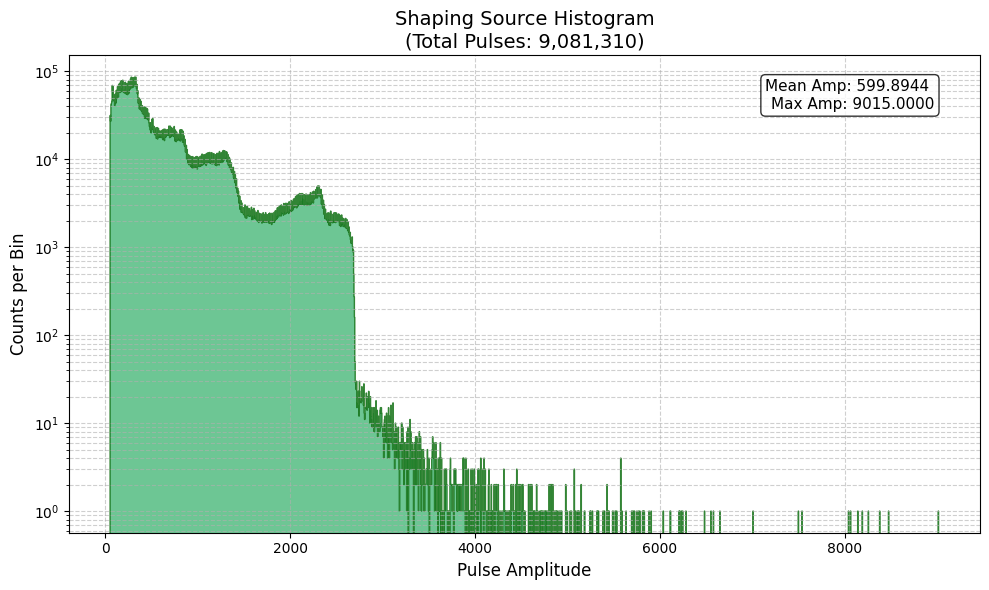

In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def extract_pulse_amplitudes(file_path, data_format='int16', chunk_size=10_000_000, invert_signal=False):
    """
    Reads PMT data in chunks from disk, finds pulse peaks, and returns them.
    This prevents MemoryErrors on extremely large files.
    """
    if not os.path.exists(file_path):
        print(f"Error: File '{file_path}' not found.")
        return []

    # 1. Use memmap to map the file from disk without loading it all into RAM
    data = np.memmap(file_path, dtype=data_format, mode='r')
    total_points = len(data)
    
    # Pulse parameters
    noise_threshold = 50
    min_samples_between_pulses = 10 
    
    # Create an overlap buffer so we don't split a pulse across two chunks
    overlap = min_samples_between_pulses * 2 
    
    all_peak_amplitudes = []

    # 2. Process the file in chunks
    for start_idx in range(0, total_points, chunk_size):
        end_idx = min(start_idx + chunk_size + overlap, total_points)
        
        # Extract just this specific chunk into active memory
        chunk = data[start_idx:end_idx]
        
        if invert_signal:
            analyze_chunk = chunk * -1
        else:
            analyze_chunk = chunk
            
        # Find peaks in this chunk
        peaks, _ = find_peaks(analyze_chunk, height=noise_threshold, distance=min_samples_between_pulses)
        
        # 3. Prevent double-counting in the overlap region
        if end_idx < total_points:
            valid_peaks = peaks[peaks < chunk_size]
        else:
            valid_peaks = peaks
            
        # Get the actual voltage values for these peaks
        chunk_amplitudes = chunk[valid_peaks]
        all_peak_amplitudes.extend(chunk_amplitudes)
        
    print(f"  -> Found {len(all_peak_amplitudes):,} pulses (processed {total_points:,} points).")
    
    return all_peak_amplitudes

def plot_amplitude_histogram(amplitudes, num_bins=512, log_scale=True):
    """
    Takes an array of pulse amplitudes and plots them as a histogram (spectrum).
    """
    if amplitudes is None or len(amplitudes) == 0:
        print("Error: The amplitudes array is empty. No pulses were found.")
        return

    print(f"\nPlotting combined histogram for {len(amplitudes):,} detected pulses...")

    plt.figure(figsize=(10, 6))
    
    # Plot the histogram using 'stepfilled'
    counts, bins, patches = plt.hist(amplitudes, bins=num_bins, color='mediumseagreen', 
                                     alpha=0.75, histtype='stepfilled', edgecolor='darkgreen')
    
    # Apply Logarithmic Scale
    if log_scale:
        plt.yscale('log')
        plt.grid(True, linestyle='--', alpha=0.6, which='both') 
    else:
        plt.grid(True, linestyle='--', alpha=0.6)

    # Stats
    mean_amp = np.mean(amplitudes)
    max_amp = np.max(amplitudes)
    
    plt.title(f"Shaping Source Histogram\n(Total Pulses: {len(amplitudes):,})", fontsize=14)
    plt.xlabel("Pulse Amplitude", fontsize=12)
    plt.ylabel("Counts per Bin", fontsize=12)
    
    # Add a text box with statistics
    stats_text = f"Mean Amp: {mean_amp:.4f} \nMax Amp: {max_amp:.4f}"
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()


# ==========================================
# Main Execution Block
# ==========================================

# 1. Define the folder containing your files
folder_path = r"C:\Users\Berkeley\Documents\CERES\welding_rod_200khz"

# 2. Find all .BINPMT files in that folder
file_pattern = os.path.join(folder_path, "*.BINPMT")
file_list = glob.glob(file_pattern)

if not file_list:
    print(f"No .BINPMT files found in {folder_path}")
else:
    print(f"Found {len(file_list)} files to process.\n")

    # List to hold all amplitudes across all files
    all_amplitudes = []

    # 3. Loop through the files
    for file_path in file_list:
        file_name = os.path.basename(file_path)
        print(f"Processing: {file_name}")
        
        # Extract pulses (processing in chunks to save memory)
        # Replaced num_points with chunk_size
        file_amplitudes = extract_pulse_amplitudes(file_path, chunk_size=10_000_000, invert_signal=False)
        
        # Add the extracted amplitudes to our master list
        if file_amplitudes is not None and len(file_amplitudes) > 0:
            all_amplitudes.extend(file_amplitudes)

    # 4. Convert the combined list to a numpy array for plotting
    all_amplitudes = np.array(all_amplitudes)

    # 5. Plot the combined spectrum!
    plot_amplitude_histogram(all_amplitudes, num_bins=2048, log_scale=True)